In [9]:
from rasterio.io import MemoryFile
import pandas as pd
import os
import matplotlib.pyplot as plt

In [5]:
path = "boyaUPCT"
filename = "locBoyasUPCT.csv"
loc_boyas = pd.read_csv(os.path.join(path, filename)).iloc[:,:3]
loc_boyas.head(3)

,CodPuntoControl,Latitud,Longitud
0,CTD-1,37.811800,-0.784483
1,CTD-2,37.760617,-0.807800
2,CTD-3,37.761783,-0.783550


In [ ]:
def coordenadas_a_pixel(response, lat, lon, buoy):
    """
    Extract pixel value and coordinates from a TIFF response using latitude and longitude.
    """
    if response.status_code == 200:
        # Read the TIFF content from the response
        with MemoryFile(response.content) as memfile:
            with memfile.open() as src:
                # Read the first band of the TIFF file
                index_array = src.read(1)  # Assuming single-band data
                
                # Get the pixel coordinates for the given latitude and longitude
                row, col = src.index(lon, lat)
                
                # Extract the value from the index array
                value = index_array[row, col]
                
                # Print for debugging
                print(f"Loc Buoy {buoy} - Pixel value: {value}, Latitude: {lat}, Longitude: {lon}")
                
                return row, col, value
    else:
        print(f"Request failed with status code: {response.status_code}")
        return None


In [3]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]

    for archivo in archivos_csv:
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        # CARGAMOS SOLO CLOROFILA
        if nombre_variable in ["Clorofila"]:
            dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
        
for key, df in dataframes_boyas.items():
    df['Date'] = pd.to_datetime(df['Date'])

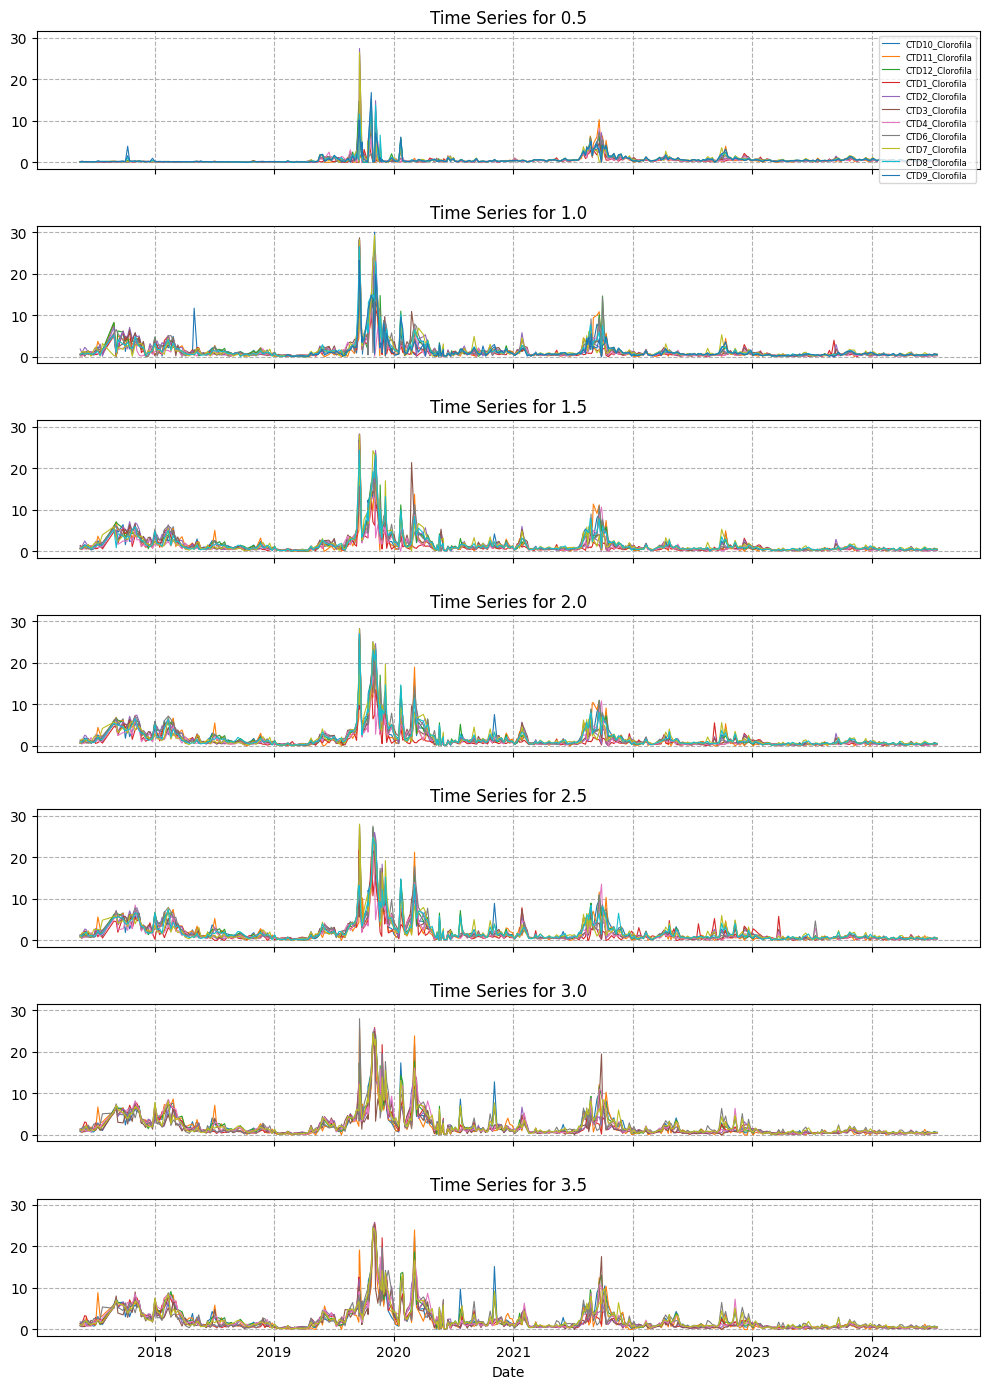

In [30]:
def plot_depths(df_dict):
    columns = ['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5'] #['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
    num_plots = len(columns)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 2 * num_plots), sharex=True, sharey=True)
    
    for i, col in enumerate(columns):
        for name in sorted(df_dict.keys()):
            df = df_dict[name]
            if col in df.columns:
                axes[i].plot(df['Date'], df[col], label=name, linewidth=0.8)
        
        axes[i].set_title(f'Time Series for {col}')
        axes[i].grid(linestyle='--')
        
        if i == 0:
            axes[i].legend(loc="upper right", fontsize = 6)
    
    plt.xlabel('Date')
    fig.tight_layout()
    plt.show()

plot_depths(dataframes_boyas)

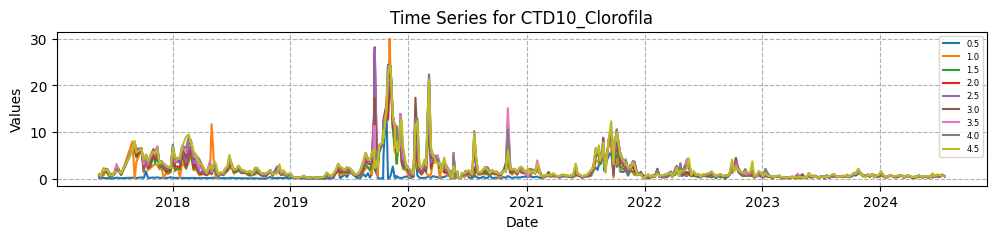

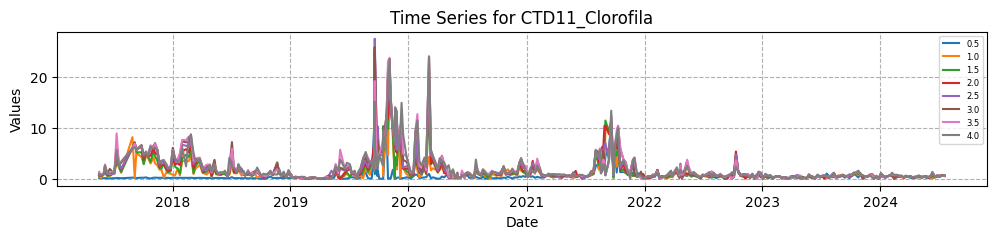

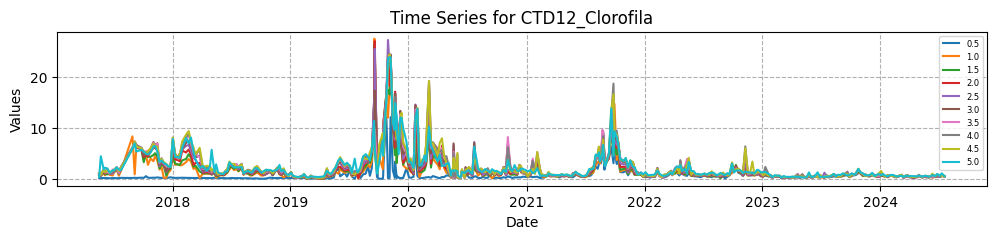

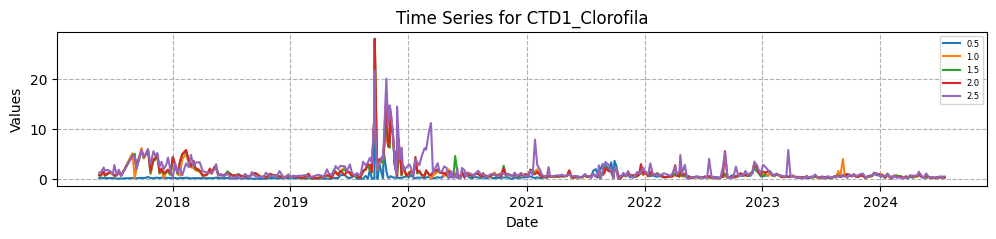

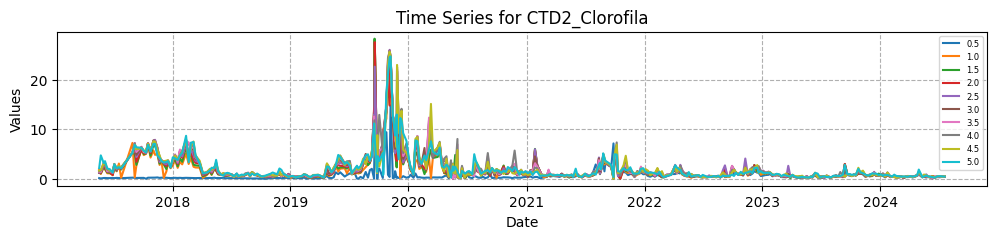

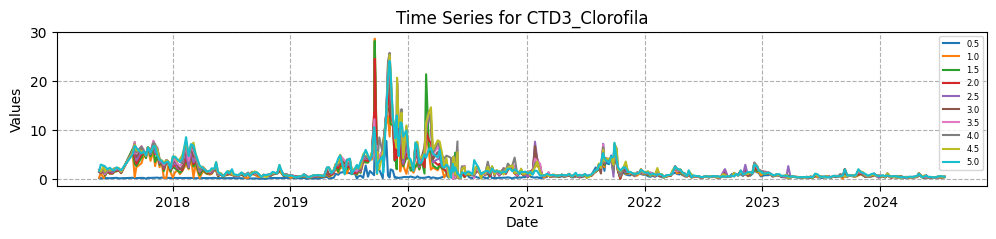

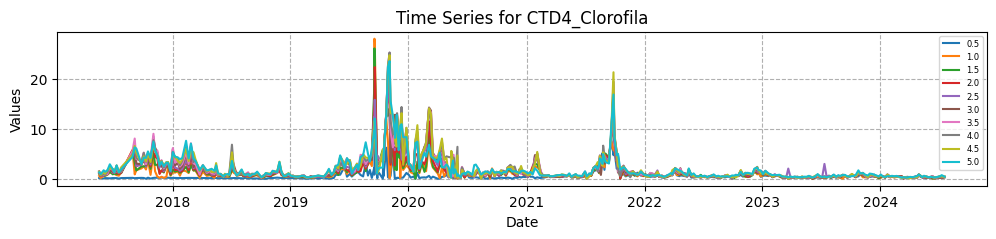

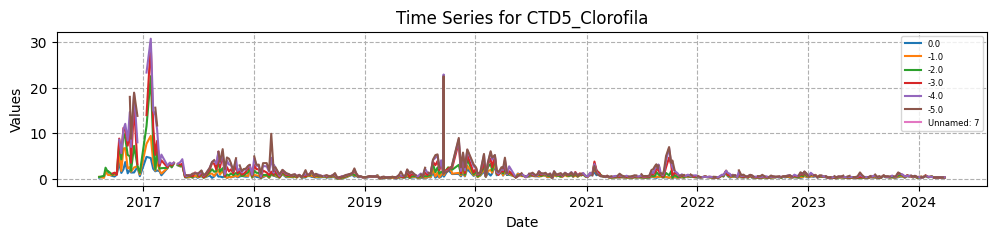

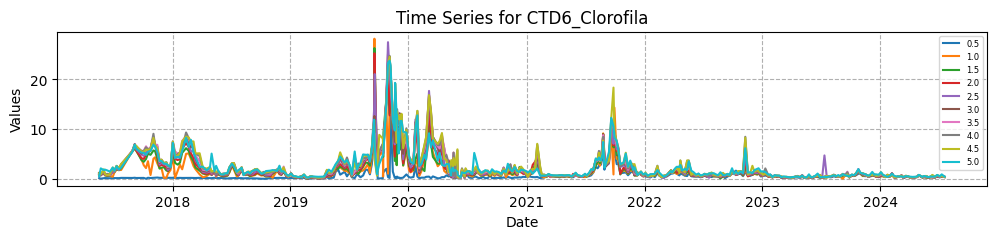

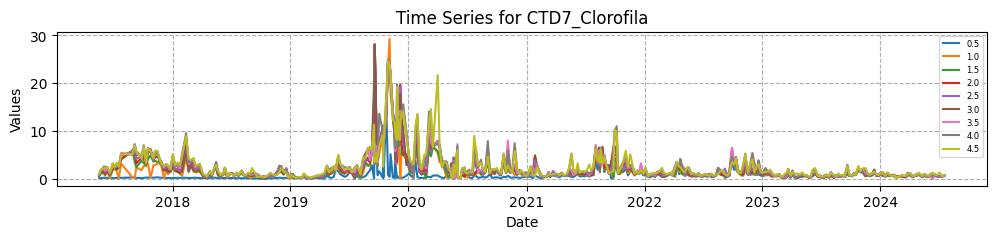

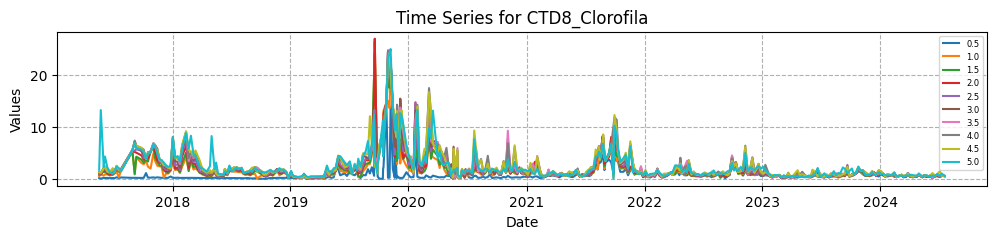

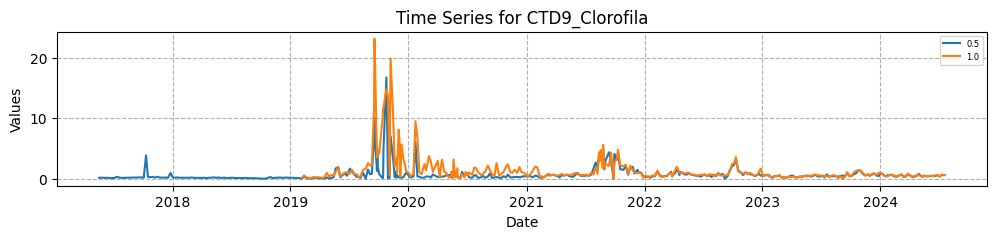

In [28]:
def plot_buoys(df_dict):
    for name in sorted(df_dict.keys()):
        df = df_dict[name]
        fig, ax = plt.subplots(figsize=(12, 2))
        for col in df.columns:
            if col != 'Date':
                ax.plot(df['Date'], df[col], label=col)
        
        ax.set_title(f'Time Series for {name}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Values')
        ax.legend(loc="upper right", fontsize = 6)
        ax.grid(linestyle='--')
        plt.show()

plot_buoys(dataframes_boyas)